# Main Analysis

Phase 3 establishes reproducible data loading and initial dataset inspection. Phase 4 adds exploratory analysis while deliberately excluding model training and production feature engineering.

## 1. Project setup

The setup locates the repository without embedding a machine-specific path and imports the shared loading utilities.

In [1]:
from pathlib import Path
import platform
import sys

import pandas as pd
from IPython.display import Markdown, display

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').is_dir():
    raise ValueError('Run this notebook from the project root or the notebooks directory.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loading import (
    detect_constant_columns,
    detect_duplicate_columns,
    get_data_paths,
    load_available_transaction_files,
    load_transactions,
    summarize_dataframe,
    validate_transaction_schema,
)

pd.set_option('display.max_columns', 20)
print(f'Python {platform.python_version()} | pandas {pd.__version__}')

Python 3.12.13 | pandas 2.2.3


## 2. Dataset source and scope

The data come from the [Fraud Detection Handbook simulated-data repository](https://github.com/Fraud-Detection-Handbook/simulated-data-raw). Each file contains one day of labeled payment-card transactions. This notebook inspects the raw fields only; the handbook's transformed dataset is outside this phase.

The data are synthetic. Their transparency supports internal reproduction, but results on them cannot by themselves establish performance on a real payment system.

## 3. Data loading

The loader reads daily pickle files in date order and performs no preprocessing. If the data are missing, it stops with the official source and the exact acquisition command.

In [2]:
data_paths = get_data_paths(project_root)
transaction_files = load_available_transaction_files(data_paths['transactions'])
print(
    f'Discovered {len(transaction_files)} daily files: '
    f'{transaction_files[0].name} through {transaction_files[-1].name}.'
)

transactions = load_transactions(data_paths['transactions'])
print('Transaction files loaded without feature transformation.')

Discovered 183 daily files: 2018-04-01.pkl through 2018-09-30.pkl.


Transaction files loaded without feature transformation.


## 4. Schema validation

Schema validation checks required fields, datetime representation, and the documented fraud-label domains. It does not silently coerce invalid data.

In [3]:
validate_transaction_schema(transactions)
print('Schema validation passed for the documented raw transaction fields.')

Schema validation passed for the documented raw transaction fields.


`TX_FRAUD` is the binary prediction target. `TX_FRAUD_SCENARIO` explains which simulator rule assigned a fraud label and must never be used as a predictor because it directly reveals the target-generation mechanism.

## 5. Dataset size

The structural summary records the observation count, field count, in-memory size, missing cells, duplicate rows, and index representation.

In [4]:
dataset_summary = summarize_dataframe(transactions)
display(dataset_summary.to_frame())
display(
    Markdown(
        f"The loaded table contains **{int(dataset_summary['rows']):,} transactions** "
        f"and **{int(dataset_summary['columns'])} raw columns**. Each row is one "
        "labeled transaction event rather than an aggregated customer record."
    )
)

,value
rows,1754155
columns,9
memory_mib,307.81
missing_cells,0
duplicate_rows,0
index_type,RangeIndex
index_name,<unnamed>


The loaded table contains **1,754,155 transactions** and **9 raw columns**. Each row is one labeled transaction event rather than an aggregated customer record.

## 6. Column and index inspection

Column names should preserve the simulator's documented semantics. The DataFrame index is inspected separately from the transaction identifier.

In [5]:
column_positions = pd.DataFrame(
    {'position': range(len(transactions.columns)), 'column': transactions.columns}
)
display(column_positions)

index_inspection = pd.Series(
    {
        'index_type': type(transactions.index).__name__,
        'index_name': transactions.index.name or '<unnamed>',
        'index_is_unique': transactions.index.is_unique,
        'transaction_id_is_unique': transactions['TRANSACTION_ID'].is_unique,
    },
    name='value',
)
display(index_inspection.to_frame())

,position,column
0,0,TRANSACTION_ID
1,1,TX_DATETIME
2,2,CUSTOMER_ID
3,3,TERMINAL_ID
4,4,TX_AMOUNT
5,5,TX_TIME_SECONDS
6,6,TX_TIME_DAYS
7,7,TX_FRAUD
8,8,TX_FRAUD_SCENARIO


,value
index_type,RangeIndex
index_name,<unnamed>
index_is_unique,True
transaction_id_is_unique,True


In [6]:
id_interpretation = (
    '`TRANSACTION_ID` is unique and is the meaningful event identifier.'
    if transactions['TRANSACTION_ID'].is_unique
    else '`TRANSACTION_ID` is not unique; this requires investigation before modeling.'
)
display(
    Markdown(
        'The unnamed `RangeIndex` is only an in-memory row position after concatenation. '
        + id_interpretation
        + ' Identifier columns should not be treated as continuous predictors.'
    )
)

The unnamed `RangeIndex` is only an in-memory row position after concatenation. `TRANSACTION_ID` is unique and is the meaningful event identifier. Identifier columns should not be treated as continuous predictors.

## 7. Feature types

Storage dtypes are paired with analytical roles so that identifiers, timestamps, predictors, and labels are not confused.

In [7]:
semantic_roles = {
    'TRANSACTION_ID': 'event identifier; exclude from predictors',
    'TX_DATETIME': 'event time; use for ordering and temporal splitting',
    'CUSTOMER_ID': 'entity identifier; categorical semantics',
    'TERMINAL_ID': 'entity identifier; categorical semantics',
    'TX_AMOUNT': 'continuous transaction attribute',
    'TX_TIME_SECONDS': 'elapsed-time representation',
    'TX_TIME_DAYS': 'day index for temporal grouping',
    'TX_FRAUD': 'binary target; exclude from predictors',
    'TX_FRAUD_SCENARIO': 'simulator explanation label; leakage if used as predictor',
}

feature_types = pd.DataFrame(
    {
        'dtype': transactions.dtypes.astype(str),
        'non_missing': transactions.notna().sum(),
        'distinct_values': transactions.nunique(dropna=False),
        'analytical_role': pd.Series(semantic_roles),
    }
)
display(feature_types)

,dtype,non_missing,distinct_values,analytical_role
TRANSACTION_ID,int64,1754155,1754155,event identifier; exclude from predictors
TX_DATETIME,datetime64[ns],1754155,1635076,event time; use for ordering and temporal spli...
CUSTOMER_ID,object,1754155,4990,entity identifier; categorical semantics
TERMINAL_ID,object,1754155,10000,entity identifier; categorical semantics
TX_AMOUNT,float64,1754155,24585,continuous transaction attribute
TX_TIME_SECONDS,object,1754155,1635076,elapsed-time representation
TX_TIME_DAYS,object,1754155,183,day index for temporal grouping
TX_FRAUD,int64,1754155,2,binary target; exclude from predictors
TX_FRAUD_SCENARIO,int64,1754155,4,simulator explanation label; leakage if used a...


Customer and terminal identifiers are stored as integers, but their numbers do not represent magnitude. Treating them as ordinary continuous quantities would create meaningless distance relationships.

## 8. Missing-value analysis

Missingness is measured per field before any imputation decision.

In [8]:
missing_values = pd.DataFrame(
    {
        'missing_count': transactions.isna().sum(),
        'missing_percent': transactions.isna().mean().mul(100).round(4),
    }
)
display(missing_values)

if missing_values['missing_count'].sum() == 0:
    missing_interpretation = (
        'No missing cells were found. This is consistent with a controlled simulator, '
        'but it understates the incomplete records expected in operational payment data.'
    )
else:
    missing_interpretation = (
        'Missing values are present and must be explained before any imputation; '
        'blind filling could erase fraud-relevant collection failures.'
    )
display(Markdown(missing_interpretation))

,missing_count,missing_percent
TRANSACTION_ID,0,0.0
TX_DATETIME,0,0.0
CUSTOMER_ID,0,0.0
TERMINAL_ID,0,0.0
TX_AMOUNT,0,0.0
TX_TIME_SECONDS,0,0.0
TX_TIME_DAYS,0,0.0
TX_FRAUD,0,0.0
TX_FRAUD_SCENARIO,0,0.0


No missing cells were found. This is consistent with a controlled simulator, but it understates the incomplete records expected in operational payment data.

## 9. Duplicate-row analysis

Exact duplicate events may indicate accidental repeated ingestion. Repeated customers, terminals, amounts, or timestamps alone are not duplicate transactions.

In [9]:
duplicate_row_count = int(dataset_summary['duplicate_rows'])
duplicate_row_percent = duplicate_row_count / len(transactions) * 100
display(
    pd.Series(
        {
            'duplicate_rows': duplicate_row_count,
            'duplicate_percent': round(duplicate_row_percent, 6),
        },
        name='value',
    ).to_frame()
)

duplicate_interpretation = (
    'No exact duplicate transaction rows were found.'
    if duplicate_row_count == 0
    else 'Exact duplicate rows exist and may inflate both prevalence and validation scores.'
)
display(Markdown(duplicate_interpretation))

,value
duplicate_rows,0.0
duplicate_percent,0.0


No exact duplicate transaction rows were found.

## 10. Constant-feature and duplicate-feature analysis

A constant column has no discriminatory information. An exact duplicate column adds no new information and can distort interpretation or unnecessarily increase computation.

In [10]:
constant_columns = detect_constant_columns(transactions)
duplicate_columns = detect_duplicate_columns(transactions)
display(
    pd.Series(
        {
            'constant_columns': constant_columns or '<none>',
            'duplicate_columns': duplicate_columns or '<none>',
        },
        name='finding',
    ).to_frame()
)

if not constant_columns and not duplicate_columns:
    feature_redundancy_interpretation = (
        'No constant or exactly duplicated raw columns were found. This does not rule '
        'out high correlation or semantic redundancy, which belongs to later analysis.'
    )
else:
    feature_redundancy_interpretation = (
        'Constant or duplicate fields should be excluded from predictive inputs after '
        'their provenance is checked.'
    )
display(Markdown(feature_redundancy_interpretation))

,finding
constant_columns,<none>
duplicate_columns,<none>


No constant or exactly duplicated raw columns were found. This does not rule out high correlation or semantic redundancy, which belongs to later analysis.

## 11. Target/class prevalence

Fraud prevalence determines whether accuracy is informative and establishes the operational scale of false positives and false negatives.

In [11]:
class_counts = transactions['TX_FRAUD'].value_counts().sort_index()
class_prevalence = pd.DataFrame(
    {
        'label_name': ['legitimate', 'fraud'],
        'count': class_counts.reindex([0, 1], fill_value=0),
    },
    index=pd.Index([0, 1], name='TX_FRAUD'),
)
class_prevalence['percent'] = (
    class_prevalence['count'] / class_prevalence['count'].sum() * 100
).round(4)
display(class_prevalence)

fraud_count = int(class_prevalence.loc[1, 'count'])
legitimate_count = int(class_prevalence.loc[0, 'count'])
fraud_rate = fraud_count / len(transactions)
imbalance_ratio = legitimate_count / fraud_count if fraud_count else float('inf')
display(
    Markdown(
        f'Fraud prevalence is **{fraud_rate:.3%}**, or approximately one fraud for '
        f'every **{imbalance_ratio:.1f} legitimate transactions**. A classifier that '
        'predicts every event as legitimate would appear accurate while detecting no '
        'fraud, so accuracy alone is unsuitable.'
    )
)

,label_name,count,percent
TX_FRAUD,,,
0,legitimate,1739474,99.1631
1,fraud,14681,0.8369


Fraud prevalence is **0.837%**, or approximately one fraud for every **118.5 legitimate transactions**. A classifier that predicts every event as legitimate would appear accurate while detecting no fraud, so accuracy alone is unsuitable.

## 12. Initial temporal coverage check

Only coverage and ordering are checked here. Temporal distributions and concept drift belong to later EDA.

In [12]:
start_timestamp = transactions['TX_DATETIME'].min()
end_timestamp = transactions['TX_DATETIME'].max()
calendar_days = (end_timestamp.normalize() - start_timestamp.normalize()).days + 1
temporal_summary = pd.Series(
    {
        'first_timestamp': start_timestamp,
        'last_timestamp': end_timestamp,
        'calendar_days_covered': calendar_days,
        'daily_files': len(transaction_files),
        'rows_are_chronological': transactions['TX_DATETIME'].is_monotonic_increasing,
    },
    name='value',
)
display(temporal_summary.to_frame())
display(
    Markdown(
        f'The transactions cover **{calendar_days} calendar days**. Time is part of the '
        'security context: randomly mixing later transactions into training could expose '
        'the model to patterns unavailable at the historical prediction date. Later '
        'validation must therefore preserve chronology and the handbook feedback delay.'
    )
)

,value
first_timestamp,2018-04-01 00:00:31
last_timestamp,2018-09-30 23:59:57
calendar_days_covered,183
daily_files,183
rows_are_chronological,True


The transactions cover **183 calendar days**. Time is part of the security context: randomly mixing later transactions into training could expose the model to patterns unavailable at the historical prediction date. Later validation must therefore preserve chronology and the handbook feedback delay.

## 13. Short cybersecurity interpretation

This section consolidates only the verified inspection findings.

In [13]:
integrity_statement = (
    'No missing cells, exact duplicate rows, constant columns, or duplicate columns '
    'were detected in the raw table.'
    if (
        missing_values['missing_count'].sum() == 0
        and duplicate_row_count == 0
        and not constant_columns
        and not duplicate_columns
    )
    else 'The integrity findings above require resolution before predictive modeling.'
)

display(
    Markdown(
        f'- {integrity_statement}\n'
        f'- Fraud prevalence is {fraud_rate:.3%}; class-sensitive metrics will be required.\n'
        '- `TRANSACTION_ID` is an event key, while `TX_FRAUD_SCENARIO` is an explanatory '
        'label that would leak the target-generation rule if used as a feature.\n'
        '- The dataset is temporally ordered and must be split by time rather than by '
        'random row assignment.\n'
        '- These checks support internal data integrity only. Synthetic cleanliness and '
        'known fraud rules do not establish external validity.'
    )
)

- No missing cells, exact duplicate rows, constant columns, or duplicate columns were detected in the raw table.
- Fraud prevalence is 0.837%; class-sensitive metrics will be required.
- `TRANSACTION_ID` is an event key, while `TX_FRAUD_SCENARIO` is an explanatory label that would leak the target-generation rule if used as a feature.
- The dataset is temporally ordered and must be split by time rather than by random row assignment.
- These checks support internal data integrity only. Synthetic cleanliness and known fraud rules do not establish external validity.

## 14. Exploratory analysis overview

This phase examines distributions, data quality, temporal behavior, class imbalance, group-level fraud prevalence, and bivariate association. All derived bins, flags, and aggregates are temporary analytical objects. No model is fitted, and no full-period aggregate is proposed as a deployable feature.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.eda import (
    compute_class_prevalence,
    compute_correlation_matrix,
    compute_daily_transaction_summary,
    compute_grouped_fraud_rates,
    compute_hourly_fraud_summary,
    compute_missing_summary,
    compute_outlier_summary_iqr,
    save_figure,
    summarize_categorical_features,
    summarize_numeric_features,
)

figures_dir = project_root / 'figures'
sns.set_theme(style='whitegrid', context='notebook')
fraud_palette = {0: '#4C78A8', 1: '#E45756'}
print('EDA utilities loaded; no estimator has been instantiated.')

Matplotlib is building the font cache; this may take a moment.


EDA utilities loaded; no estimator has been instantiated.


## 15. Feature distributions

Raw transaction amount is analyzed on both its original scale and an EDA-only `log1p` scale. The logarithm improves visualization of a right-skewed distribution; it does not alter the loaded table. The source pickles store both time counters with object dtype despite containing integer values, so a checked, temporary numeric view is used for their summary.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,zero_count,skew
TX_AMOUNT,1754155.0,53.632,42.326,0.0,1.97,6.0,21.01,44.64,76.95,130.94,171.59,2628.0,0,42,2.444
TX_TIME_SECONDS,1754155.0,7903233.709,4565172.384,31.0,148573.32,802224.1,3940846.50,7902670.00,11865661.50,15008721.20,15662921.00,15811197.0,0,0,0.001
TX_TIME_DAYS,1754155.0,90.973,52.837,0.0,1.00,9.0,45.00,91.00,137.00,173.00,181.00,182.0,0,9488,0.001


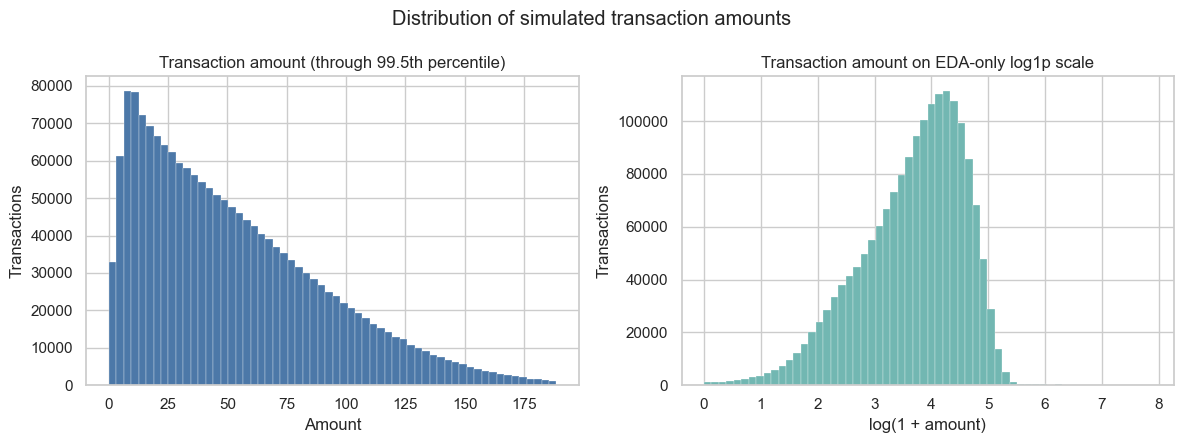

`TX_AMOUNT` has skewness **2.44**; its median is **44.64**, while the 99th percentile is **171.59**. The separation supports distribution-aware analysis and later scaling tests, but does not justify deleting high-value transactions.

In [15]:
numeric_eda_columns = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS']
eda_numeric_frame = transactions[numeric_eda_columns].copy()
for column in ['TX_TIME_SECONDS', 'TX_TIME_DAYS']:
    eda_numeric_frame[column] = pd.to_numeric(eda_numeric_frame[column], errors='raise')
numeric_summary = summarize_numeric_features(eda_numeric_frame, numeric_eda_columns)
display(numeric_summary.round(3))

amount_clip = transactions['TX_AMOUNT'].quantile(0.995)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(
    transactions.loc[transactions['TX_AMOUNT'] <= amount_clip, 'TX_AMOUNT'],
    bins=60, color=fraud_palette[0], edgecolor='white', linewidth=0.2,
)
axes[0].set(title='Transaction amount (through 99.5th percentile)', xlabel='Amount', ylabel='Transactions')
axes[1].hist(
    np.log1p(transactions['TX_AMOUNT']), bins=60,
    color='#72B7B2', edgecolor='white', linewidth=0.2,
)
axes[1].set(title='Transaction amount on EDA-only log1p scale', xlabel='log(1 + amount)', ylabel='Transactions')
figure.suptitle('Distribution of simulated transaction amounts')
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'transaction_amount_distribution.png')
plt.show()
display(Markdown(
    f'`TX_AMOUNT` has skewness **{numeric_summary.loc["TX_AMOUNT", "skew"]:.2f}**; '
    f'its median is **{numeric_summary.loc["TX_AMOUNT", "50%"]:.2f}**, while the 99th percentile is '
    f'**{numeric_summary.loc["TX_AMOUNT", "99%"]:.2f}**. The separation supports distribution-aware '
    'analysis and later scaling tests, but does not justify deleting high-value transactions.'
))

## 16. Missing-value patterns

Missingness is recomputed with a reusable helper. Complete synthetic data simplify reproduction, but they also omit operational failure modes such as unavailable attributes, delayed records, and upstream collection changes.

In [16]:
eda_missing_summary = compute_missing_summary(transactions)
display(eda_missing_summary)
display(Markdown(
    f'The EDA audit finds **{int(eda_missing_summary["missing_count"].sum()):,} missing cells**. '
    'This confirms internal completeness; it is not evidence that an equivalent production feed would be complete.'
))

,missing_count,missing_percent
column,,
TRANSACTION_ID,0,0.0
TX_DATETIME,0,0.0
CUSTOMER_ID,0,0.0
TERMINAL_ID,0,0.0
TX_AMOUNT,0,0.0
TX_TIME_SECONDS,0,0.0
TX_TIME_DAYS,0,0.0
TX_FRAUD,0,0.0
TX_FRAUD_SCENARIO,0,0.0


The EDA audit finds **0 missing cells**. This confirms internal completeness; it is not evidence that an equivalent production feed would be complete.

## 17. Outlier analysis

Tukey's 1.5-IQR rule is used descriptively. The temporary flag below is not written back to the dataset, and flagged amounts are not removed because rare, high-value events may be security-relevant rather than erroneous.

In [17]:
amount_outlier_summary = compute_outlier_summary_iqr(transactions, ['TX_AMOUNT'])
display(amount_outlier_summary.round(3))
display(
    transactions['TX_AMOUNT']
    .quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00])
    .rename('TX_AMOUNT')
    .to_frame()
)

amount_upper_bound = amount_outlier_summary.loc['TX_AMOUNT', 'upper_bound']
eda_amount_outlier = transactions['TX_AMOUNT'] > amount_upper_bound
outlier_label_table = pd.crosstab(
    eda_amount_outlier.rename('above_iqr_upper_bound'),
    transactions['TX_FRAUD'],
    margins=True,
)
display(outlier_label_table)
outlier_fraud_rate = transactions.loc[eda_amount_outlier, 'TX_FRAUD'].mean()
fraud_above_bound_share = eda_amount_outlier[transactions['TX_FRAUD'].eq(1)].mean()
display(Markdown(
    f'Amounts above the IQR upper bound have a fraud rate of **{outlier_fraud_rate:.2%}**, and '
    f'**{fraud_above_bound_share:.2%}** of fraud observations exceed that bound. The overlap is substantial '
    'but incomplete, so a generic outlier rule is neither a fraud definition nor a defensible cleaning rule.'
))

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
column,,,,,,,
TX_AMOUNT,21.01,76.95,55.94,-62.9,160.86,27449,1.565


,TX_AMOUNT
0.500,44.6400
0.900,110.1200
0.950,130.9400
0.990,171.5900
0.995,188.6100
0.999,289.9461
1.000,2628.0000


TX_FRAUD,0,1,All
above_iqr_upper_bound,,,
False,1715950,10756,1726706
True,23524,3925,27449
All,1739474,14681,1754155


Amounts above the IQR upper bound have a fraud rate of **14.30%**, and **26.74%** of fraud observations exceed that bound. The overlap is substantial but incomplete, so a generic outlier rule is neither a fraud definition nor a defensible cleaning rule.

## 18. Temporal transaction volume

Daily counts reveal whether the simulator is stable over the observation window and whether later evaluation periods differ in exposure volume.

,transactions
count,183.00
mean,9585.55
std,96.89
min,9285.00
25%,9522.00
50%,9581.00
75%,9656.50
max,9789.00


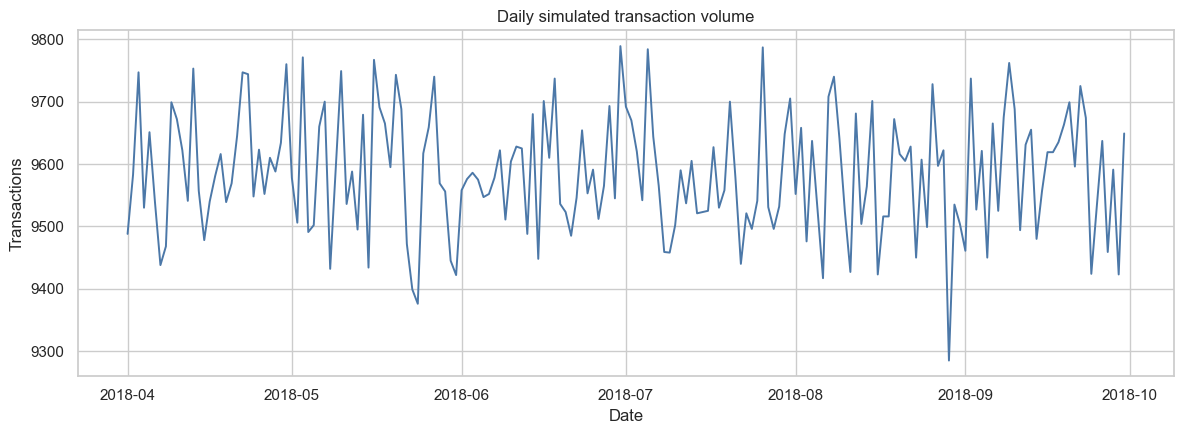

Daily volume ranges from **9,285** to **9,789** transactions, with a median of **9,581**. Temporal order remains essential even when aggregate volume appears broadly stable.

In [18]:
daily_summary = compute_daily_transaction_summary(transactions, 'TX_DATETIME', 'TX_FRAUD')
display(daily_summary[['transactions']].describe().round(2))

figure, axis = plt.subplots(figsize=(12, 4.5))
axis.plot(daily_summary.index, daily_summary['transactions'], color=fraud_palette[0], linewidth=1.4)
axis.set(title='Daily simulated transaction volume', xlabel='Date', ylabel='Transactions')
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'transactions_over_time.png')
plt.show()
display(Markdown(
    f'Daily volume ranges from **{daily_summary["transactions"].min():,}** to '
    f'**{daily_summary["transactions"].max():,}** transactions, with a median of '
    f'**{daily_summary["transactions"].median():,.0f}**. Temporal order remains essential even when '
    'aggregate volume appears broadly stable.'
))

## 19. Temporal fraud prevalence

Fraud counts and fraud rates are shown separately because changing exposure can move the count without changing risk. Day-to-day variation also demonstrates why random row splits would conceal temporal drift and allow future behavior into training.

,fraud_count,fraud_rate
count,183.00000,183.00000
mean,80.22404,0.00837
std,17.10597,0.00178
min,3.00000,0.00032
25%,76.00000,0.00792
50%,84.00000,0.00869
75%,90.00000,0.00936
max,110.00000,0.01139


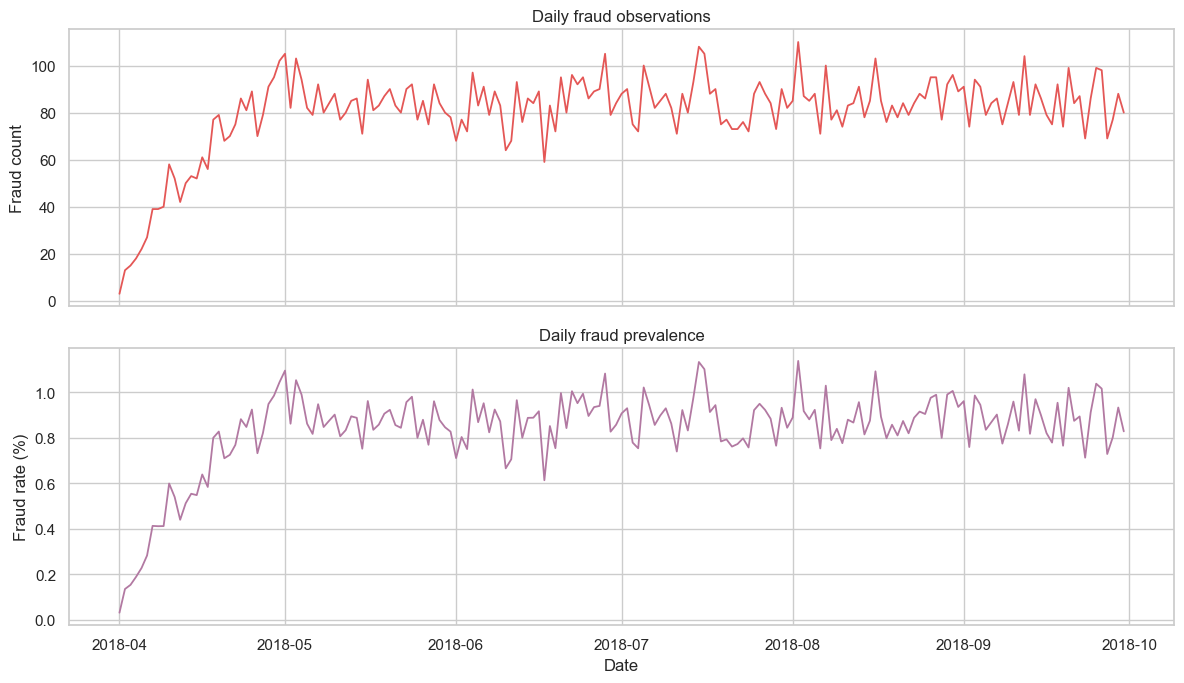

Daily fraud prevalence ranges from **0.032%** to **1.139%**. This time dependence supports chronological validation and cautions against treating observations as exchangeable.

In [19]:
display(daily_summary[['fraud_count', 'fraud_rate']].describe().round(5))
figure, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily_summary.index, daily_summary['fraud_count'], color=fraud_palette[1], linewidth=1.3)
axes[0].set(title='Daily fraud observations', ylabel='Fraud count')
axes[1].plot(daily_summary.index, daily_summary['fraud_rate'] * 100, color='#B279A2', linewidth=1.3)
axes[1].set(title='Daily fraud prevalence', xlabel='Date', ylabel='Fraud rate (%)')
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'fraud_prevalence_over_time.png')
plt.show()
display(Markdown(
    f'Daily fraud prevalence ranges from **{daily_summary["fraud_rate"].min():.3%}** to '
    f'**{daily_summary["fraud_rate"].max():.3%}**. This time dependence supports chronological '
    'validation and cautions against treating observations as exchangeable.'
))

## 20. Transaction amount by fraud label

Label-specific distributions test the handbook simulator's documented amount-related mechanism without treating amount as a sufficient explanation of fraud. Density curves are displayed on an EDA-only logarithmic scale so that both classes remain visible.

,count,mean,median,p95,p99,maximum
TX_FRAUD,,,,,,
0,1739474,52.98,44.49,129.72,167.04,219.98
1,14681,131.17,72.22,470.00,703.33,2628.00


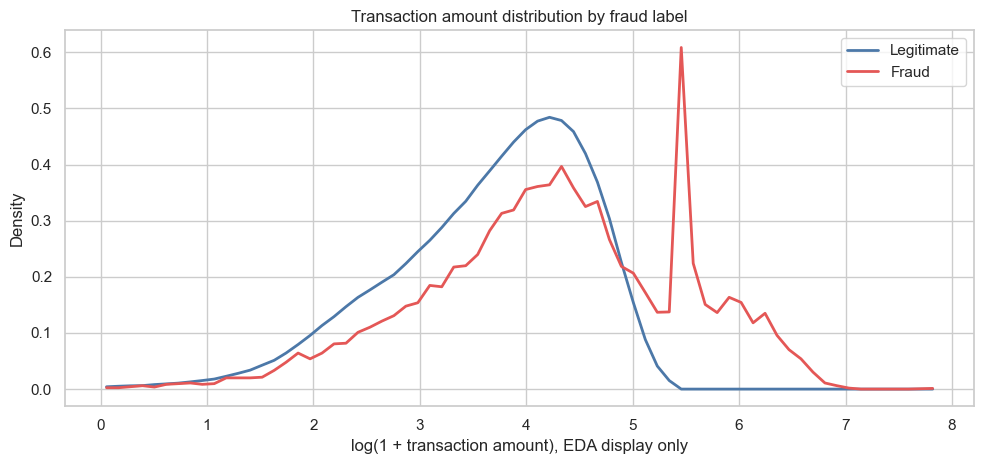

The median fraud amount is **72.22**, compared with **44.49** for legitimate transactions. The distributions still overlap, and the observed separation may partly encode the simulator rules rather than a portable real-world relationship.

In [20]:
amount_by_label = transactions.groupby('TX_FRAUD')['TX_AMOUNT'].agg(
    count='size',
    mean='mean',
    median='median',
    p95=lambda values: values.quantile(0.95),
    p99=lambda values: values.quantile(0.99),
    maximum='max',
)
display(amount_by_label.round(2))

figure, axis = plt.subplots(figsize=(10, 4.8))
for label, label_name in [(0, 'Legitimate'), (1, 'Fraud')]:
    log_amount = np.log1p(transactions.loc[transactions['TX_FRAUD'].eq(label), 'TX_AMOUNT'])
    density, bin_edges = np.histogram(log_amount, bins=70, range=(0, np.log1p(transactions['TX_AMOUNT'].max())), density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axis.plot(bin_centers, density, label=label_name, color=fraud_palette[label], linewidth=2)
axis.set(
    title='Transaction amount distribution by fraud label',
    xlabel='log(1 + transaction amount), EDA display only',
    ylabel='Density',
)
axis.legend()
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'transaction_amount_by_fraud_label.png')
plt.show()
display(Markdown(
    f'The median fraud amount is **{amount_by_label.loc[1, "median"]:.2f}**, compared with '
    f'**{amount_by_label.loc[0, "median"]:.2f}** for legitimate transactions. The distributions still '
    'overlap, and the observed separation may partly encode the simulator rules rather than a portable real-world relationship.'
))

## 21. Customer and terminal behavior

Customer and terminal identifiers are categorical entity keys, not continuous measurements. Full-period entity aggregates are used only to describe concentration. Using these same aggregates in a model would leak future outcomes unless they were recomputed strictly from prior observations at each prediction time.

In [21]:
entity_cardinality = summarize_categorical_features(
    transactions, ['CUSTOMER_ID', 'TERMINAL_ID']
)
display(entity_cardinality.round(3))

customer_eda = transactions.groupby('CUSTOMER_ID').agg(
    transactions=('TRANSACTION_ID', 'size'),
    fraud_count=('TX_FRAUD', 'sum'),
    fraud_rate=('TX_FRAUD', 'mean'),
    mean_amount=('TX_AMOUNT', 'mean'),
)
terminal_eda = transactions.groupby('TERMINAL_ID').agg(
    transactions=('TRANSACTION_ID', 'size'),
    fraud_count=('TX_FRAUD', 'sum'),
    fraud_rate=('TX_FRAUD', 'mean'),
    mean_amount=('TX_AMOUNT', 'mean'),
)
display(Markdown('**Full-period customer aggregates (descriptive only)**'))
display(customer_eda.describe().round(3))
display(Markdown('**Full-period terminal aggregates (descriptive only)**'))
display(terminal_eda.describe().round(3))
display(Markdown(
    f'Fraud is observed for **{customer_eda["fraud_count"].gt(0).mean():.2%}** of customers and '
    f'**{terminal_eda["fraud_count"].gt(0).mean():.2%}** of terminals during the full window. '
    'These rates describe simulator exposure; they cannot be used prospectively without time-aware reconstruction.'
))

,distinct_values,top_value,top_count,top_percent
column,,,,
CUSTOMER_ID,4990,382,767,0.044
TERMINAL_ID,10000,4018,376,0.021


**Full-period customer aggregates (descriptive only)**

,transactions,fraud_count,fraud_rate,mean_amount
count,4990.000,4990.000,4990.000,4990.000
mean,351.534,2.942,0.008,53.750
std,205.107,4.386,0.012,29.061
min,1.000,0.000,0.000,4.943
25%,174.000,0.000,0.000,28.597
50%,347.000,2.000,0.005,53.619
75%,531.000,4.000,0.011,78.666
max,767.000,45.000,0.200,136.922


**Full-period terminal aggregates (descriptive only)**

,transactions,fraud_count,fraud_rate,mean_amount
count,10000.000,10000.000,10000.000,10000.000
mean,175.416,1.468,0.008,53.666
std,39.170,5.145,0.028,6.416
min,47.000,0.000,0.000,33.575
25%,148.000,0.000,0.000,49.164
50%,171.000,0.000,0.000,53.610
75%,199.250,1.000,0.006,58.019
max,376.000,85.000,0.356,78.279


Fraud is observed for **69.58%** of customers and **42.66%** of terminals during the full window. These rates describe simulator exposure; they cannot be used prospectively without time-aware reconstruction.

## 22. Grouped analysis and crosstabs

Hourly and amount-bin prevalence identify nonlinear patterns that a single global rate would conceal. The bins are temporary summaries, not optimized thresholds. The fraud-scenario field is shown only as an audit of label generation and is explicitly excluded from any future predictor set.

,transactions,fraud_count,fraud_rate,fraud_rate_percent
hour,,,,
0,15137,142,0.009,0.938
1,21861,214,0.010,0.979
2,30140,246,0.008,0.816
3,40380,311,0.008,0.770
4,52403,461,0.009,0.880
5,65168,533,0.008,0.818
6,79880,675,0.008,0.845
7,94030,807,0.009,0.858
8,106617,905,0.008,0.849


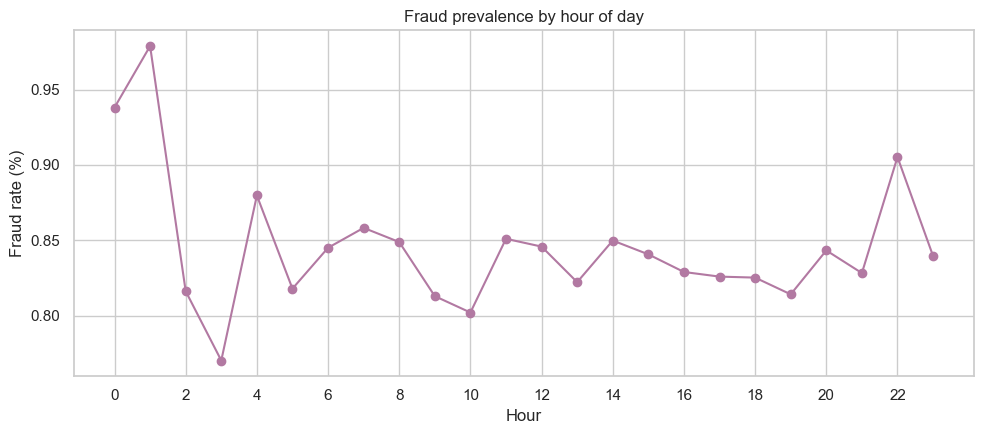

In [22]:
hourly_summary = compute_hourly_fraud_summary(transactions, 'TX_DATETIME', 'TX_FRAUD')
display(hourly_summary.assign(fraud_rate_percent=hourly_summary['fraud_rate'] * 100).round(3))

figure, axis = plt.subplots(figsize=(10, 4.5))
axis.plot(hourly_summary.index, hourly_summary['fraud_rate'] * 100, marker='o', color='#B279A2')
axis.set(
    title='Fraud prevalence by hour of day', xlabel='Hour', ylabel='Fraud rate (%)',
    xticks=range(0, 24, 2),
)
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'fraud_rate_by_hour.png')
plt.show()

,transactions,fraud_count,fraud_rate,fraud_rate_percent
EDA_AMOUNT_BIN,,,,
<25,520702,2806,0.005,0.539
25-50,441725,2618,0.006,0.593
50-100,553993,3599,0.006,0.650
100-150,195020,1563,0.008,0.801
150-220,39456,836,0.021,2.119
220-300,1584,1584,1.000,100.000
>300,1675,1675,1.000,100.000


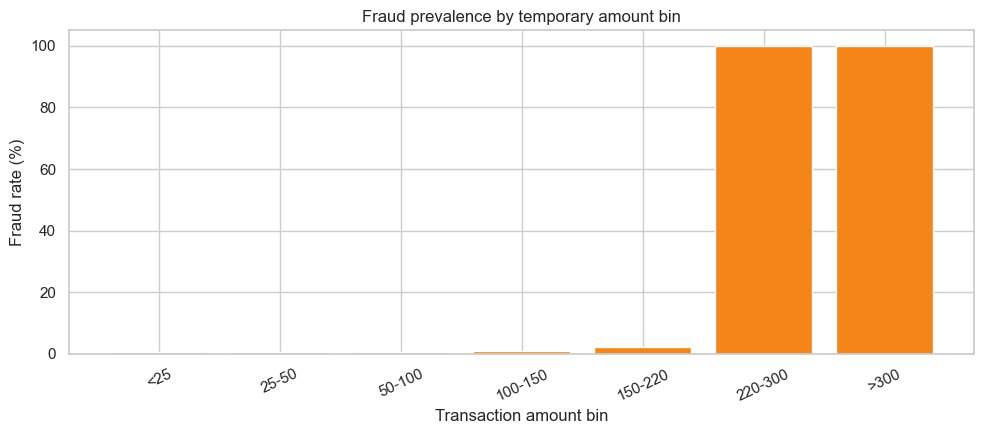

**Generator scenario audit; this field is target leakage and must not be a predictor**

,transactions,fraud_count,fraud_rate,fraud_rate_percent
TX_FRAUD_SCENARIO,,,,
0,1739474,0,0.0,0.0
1,973,973,1.0,100.0
2,9077,9077,1.0,100.0
3,4631,4631,1.0,100.0


The abrupt amount-bin differences and deterministic scenario labels are consistent with rule-based generation. They are useful for testing a workflow but may make benchmark relationships stronger and cleaner than production relationships.

In [23]:
amount_bin_edges = [-np.inf, 25, 50, 100, 150, 220, 300, np.inf]
amount_bin_labels = ['<25', '25-50', '50-100', '100-150', '150-220', '220-300', '>300']
eda_grouping_frame = transactions[['TX_AMOUNT', 'TX_FRAUD']].assign(
    EDA_AMOUNT_BIN=pd.cut(
        transactions['TX_AMOUNT'], bins=amount_bin_edges, labels=amount_bin_labels, right=False
    )
)
amount_bin_summary = compute_grouped_fraud_rates(
    eda_grouping_frame, 'EDA_AMOUNT_BIN', 'TX_FRAUD'
)
display(amount_bin_summary.assign(fraud_rate_percent=amount_bin_summary['fraud_rate'] * 100).round(3))

figure, axis = plt.subplots(figsize=(10, 4.5))
axis.bar(
    amount_bin_summary.index.astype(str), amount_bin_summary['fraud_rate'] * 100,
    color='#F58518', edgecolor='white',
)
axis.set(title='Fraud prevalence by temporary amount bin', xlabel='Transaction amount bin', ylabel='Fraud rate (%)')
axis.tick_params(axis='x', rotation=25)
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'fraud_rate_by_amount_bin.png')
plt.show()

scenario_summary = compute_grouped_fraud_rates(transactions, 'TX_FRAUD_SCENARIO', 'TX_FRAUD')
display(Markdown('**Generator scenario audit; this field is target leakage and must not be a predictor**'))
display(scenario_summary.assign(fraud_rate_percent=scenario_summary['fraud_rate'] * 100).round(3))
display(Markdown(
    'The abrupt amount-bin differences and deterministic scenario labels are consistent with rule-based generation. '
    'They are useful for testing a workflow but may make benchmark relationships stronger and cleaner than production relationships.'
))

## 23. Correlation methodology

**Pearson correlation** standardizes covariance and measures linear association. It is interpretable for continuous variables with approximately linear relationships, but it is sensitive to extreme values; common inferential uses also require stronger distributional assumptions than this skewed dataset supports.

**Spearman correlation** applies Pearson correlation to variable ranks. It measures monotonic association, is less sensitive to amount skew and extreme values, and can include a binary target as a descriptive rank association. It loses magnitude information, is affected by ties, and cannot establish causation.

**Kendall correlation** compares concordant and discordant pairs. It has a direct rank-consistency interpretation and can be attractive for smaller samples, but pairwise computation is less practical for approximately 1.75 million rows and extensive ties.

Spearman correlation is therefore selected for the explicitly listed raw numerical fields. Entity identifiers are excluded because their numeric encodings are arbitrary; `TX_FRAUD_SCENARIO` is excluded because it reveals the label-generation rule; and hour of day is excluded because an integer encoding would ignore its cyclic structure. Correlation is an association screen, not evidence of causal or operational usefulness.

## 24. Correlation analysis

The two raw time counters are retained here to expose their redundancy. Their checked numeric values come from the temporary EDA view introduced in Section 15; the loaded transaction table remains unchanged. Any later model design should avoid treating redundant encodings as independent evidence.

,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD
TX_AMOUNT,1.0000,-0.0004,-0.0004,0.0491
TX_TIME_SECONDS,-0.0004,1.0000,1.0000,0.0087
TX_TIME_DAYS,-0.0004,1.0000,1.0000,0.0087
TX_FRAUD,0.0491,0.0087,0.0087,1.0000


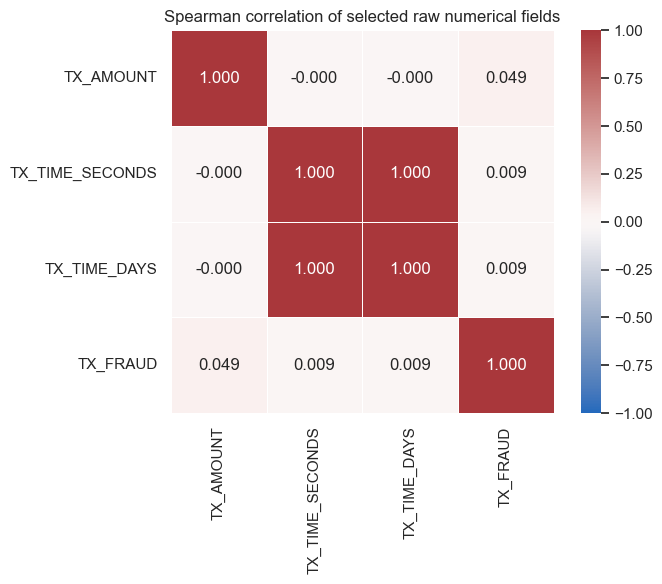

`TX_TIME_SECONDS` and `TX_TIME_DAYS` have Spearman correlation **1.0000**, confirming near-redundancy. The rank association between amount and fraud is **0.0491**. That association is descriptive and may be amplified by the simulator mechanism.

In [24]:
correlation_columns = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD']
correlation_frame = eda_numeric_frame.assign(TX_FRAUD=transactions['TX_FRAUD'].to_numpy())
spearman_correlation = compute_correlation_matrix(
    correlation_frame, correlation_columns, method='spearman'
)
display(spearman_correlation.round(4))

figure, axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    spearman_correlation, annot=True, fmt='.3f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, ax=axis,
)
axis.set_title('Spearman correlation of selected raw numerical fields')
figure.tight_layout()
_ = save_figure(figure, figures_dir / 'correlation_heatmap_spearman.png')
plt.show()
display(Markdown(
    f'`TX_TIME_SECONDS` and `TX_TIME_DAYS` have Spearman correlation '
    f'**{spearman_correlation.loc["TX_TIME_SECONDS", "TX_TIME_DAYS"]:.4f}**, confirming near-redundancy. '
    f'The rank association between amount and fraud is **{spearman_correlation.loc["TX_AMOUNT", "TX_FRAUD"]:.4f}**. '
    'That association is descriptive and may be amplified by the simulator mechanism.'
))

## 25. Class imbalance and security implications

A majority-class accuracy baseline is calculated only to demonstrate why accuracy is unsuitable. In fraud detection, false negatives can permit direct loss and continuing abuse, while false positives create review cost, declined legitimate payments, and customer friction. Evaluation must therefore consider class-sensitive threshold metrics and ranking quality in a later modeling phase.

In [25]:
class_prevalence = compute_class_prevalence(transactions, 'TX_FRAUD')
display(class_prevalence.round(5))
majority_accuracy = class_prevalence['proportion'].max()
display(Markdown(
    f'Fraud accounts for **{class_prevalence.loc[1, "count"]:,}** of **{len(transactions):,}** transactions '
    f'(**{class_prevalence.loc[1, "percent"]:.3f}%**). A classifier that predicts every transaction as '
    f'legitimate would report **{majority_accuracy:.3%} accuracy** while detecting no fraud. '
    'Precision, recall, precision-recall analysis, cost-aware thresholds, and temporally evaluated alert volumes '
    'are therefore more informative candidates for the later modeling phase.'
))

,count,proportion,percent
TX_FRAUD,,,
0,1739474,0.99163,99.16307
1,14681,0.00837,0.83693


Fraud accounts for **14,681** of **1,754,155** transactions (**0.837%**). A classifier that predicts every transaction as legitimate would report **99.163% accuracy** while detecting no fraud. Precision, recall, precision-recall analysis, cost-aware thresholds, and temporally evaluated alert volumes are therefore more informative candidates for the later modeling phase.

## 26. EDA findings and modeling implications

The final cell distinguishes observations reproduced from this benchmark from inferences that require later validation.

In [26]:
display(Markdown(
    '**Reproduced observations**\n\n'
    f'- The table contains {len(transactions):,} transactions across {len(daily_summary):,} calendar days, '
    f'with {class_prevalence.loc[1, "percent"]:.3f}% fraud.\n'
    f'- Transaction amount is right-skewed (skewness {numeric_summary.loc["TX_AMOUNT", "skew"]:.2f}) '
    'and differs by label, but the class distributions overlap.\n'
    f'- Daily fraud prevalence varies between {daily_summary["fraud_rate"].min():.3%} and '
    f'{daily_summary["fraud_rate"].max():.3%}; chronological evaluation is required.\n'
    '- Customer and terminal fraud histories concentrate risk, but full-window aggregates contain future '
    'information and are not valid prospective features.\n'
    '- Scenario identifiers deterministically expose fraud generation and must remain excluded.\n\n'
    '**Implications requiring later tests**\n\n'
    '- Behavioral features must be constructed using past-only windows before temporal validation.\n'
    '- Class imbalance makes accuracy inadequate; metric and threshold choices must reflect asymmetric errors.\n'
    '- Strong amount or entity-history results on this benchmark may reflect alignment with known generator rules. '
    'External validity therefore remains unestablished.\n\n'
    '**Phase boundary:** these observations close the EDA section; the next section begins baseline modeling.'
))

**Reproduced observations**

- The table contains 1,754,155 transactions across 183 calendar days, with 0.837% fraud.
- Transaction amount is right-skewed (skewness 2.44) and differs by label, but the class distributions overlap.
- Daily fraud prevalence varies between 0.032% and 1.139%; chronological evaluation is required.
- Customer and terminal fraud histories concentrate risk, but full-window aggregates contain future information and are not valid prospective features.
- Scenario identifiers deterministically expose fraud generation and must remain excluded.

**Implications requiring later tests**

- Behavioral features must be constructed using past-only windows before temporal validation.
- Class imbalance makes accuracy inadequate; metric and threshold choices must reflect asymmetric errors.
- Strong amount or entity-history results on this benchmark may reflect alignment with known generator rules. External validity therefore remains unestablished.

**Phase boundary:** these observations close the EDA section; the next section begins baseline modeling.

## 27. Baseline modeling scope

Phase 5 tests simple, reproducible fraud-detection baselines under chronological validation. The models intentionally use a narrow feature set: transaction amount and transaction-time encodings. The phase does not use behavioral aggregates, target-derived histories, scenario labels, or identifiers as numerical predictors. This makes the baseline conservative and leaves behavioral feature engineering for a later phase.

In [27]:
from sklearn.metrics import precision_recall_curve, roc_curve

from src.baseline_modeling import run_baseline_experiment
from src.modeling import RANDOM_SEED

results_dir = project_root / 'results'
print(f'Baseline modeling utilities loaded. Random seed: {RANDOM_SEED}.')

Baseline modeling utilities loaded. Random seed: 42.


## 28. Temporal train/validation/test split

The split is chronological by calendar day. Training uses the earliest 60% of days, validation uses the next 20%, and testing uses the final 20%. No transaction is randomly shuffled across time. The validation period is used for threshold selection, while the final test period is held out for reported model performance.

In [28]:
baseline_result = run_baseline_experiment(
    transactions,
    results_dir=results_dir,
    random_seed=RANDOM_SEED,
)

split_display = baseline_result.split_summary.copy()
split_display['fraud_rate_percent'] = split_display['fraud_rate'] * 100
display(split_display[['rows', 'days', 'start_date', 'end_date', 'fraud_count', 'fraud_rate_percent']].round(4))

,rows,days,start_date,end_date,fraud_count,fraud_rate_percent
split,,,,,,
train,1054747,110,2018-04-01,2018-07-19,8496,0.8055
validation,354264,37,2018-07-20,2018-08-25,3094,0.8734
test,345144,36,2018-08-26,2018-09-30,3091,0.8956


## 29. Leakage-safe baseline features

The baseline feature matrix includes only values available at transaction time. It excludes `TX_FRAUD`, `TX_FRAUD_SCENARIO`, transaction identifiers, customer identifiers, terminal identifiers, and full-period entity aggregates. Customer and terminal histories are potentially useful, but they must be reconstructed from past-only windows before they are valid predictors.

In [29]:
feature_roles = pd.DataFrame(
    [
        {'feature': 'tx_amount', 'role': 'raw amount observed at authorization time'},
        {'feature': 'log_tx_amount', 'role': 'monotonic amount transform computed per transaction'},
        {'feature': 'hour_sin', 'role': 'cyclic hour-of-day encoding'},
        {'feature': 'hour_cos', 'role': 'cyclic hour-of-day encoding'},
        {'feature': 'dayofweek_sin', 'role': 'cyclic day-of-week encoding'},
        {'feature': 'dayofweek_cos', 'role': 'cyclic day-of-week encoding'},
    ]
)
excluded_columns = pd.DataFrame({'excluded_raw_column': baseline_result.excluded_raw_columns})

display(feature_roles)
display(excluded_columns)

,feature,role
0,tx_amount,raw amount observed at authorization time
1,log_tx_amount,monotonic amount transform computed per transa...
2,hour_sin,cyclic hour-of-day encoding
3,hour_cos,cyclic hour-of-day encoding
4,dayofweek_sin,cyclic day-of-week encoding
5,dayofweek_cos,cyclic day-of-week encoding


,excluded_raw_column
0,TRANSACTION_ID
1,CUSTOMER_ID
2,TERMINAL_ID
3,TX_TIME_SECONDS
4,TX_TIME_DAYS
5,TX_FRAUD
6,TX_FRAUD_SCENARIO


## 30. Models and imbalance handling

Three baselines are trained. The trivial baseline assigns the training fraud prevalence to every transaction and predicts no fraud at the 0.5 threshold. Logistic regression uses class weighting. Histogram gradient boosting uses balanced sample weights. These choices address class imbalance without oversampling across time.

In [30]:
model_design = pd.DataFrame(
    [
        {
            'model': 'no_fraud_prior',
            'imbalance_handling': 'training prevalence score; no positive predictions at 0.5',
            'purpose': 'sanity-check baseline for rare-event metrics',
        },
        {
            'model': 'logistic_regression',
            'imbalance_handling': 'class_weight="balanced"',
            'purpose': 'linear baseline with calibrated feature scaling',
        },
        {
            'model': 'hist_gradient_boosting',
            'imbalance_handling': 'balanced sample weights',
            'purpose': 'nonlinear gradient-boosting baseline',
        },
    ]
)
threshold_display = baseline_result.thresholds.copy()
display(model_design)
display(threshold_display.round(6))

,model,imbalance_handling,purpose
0,no_fraud_prior,training prevalence score; no positive predict...,sanity-check baseline for rare-event metrics
1,logistic_regression,"class_weight=""balanced""",linear baseline with calibrated feature scaling
2,hist_gradient_boosting,balanced sample weights,nonlinear gradient-boosting baseline


,threshold,threshold_source,validation_precision,validation_recall,validation_f1
model,,,,,
no_fraud_prior,0.500000,fixed no-fraud decision threshold,0.000000,0.000000,0.000000
logistic_regression,0.863422,max validation F1,0.952035,0.211700,0.346378
hist_gradient_boosting,0.990102,max validation F1,0.486695,0.224628,0.307386


## 31. Test-set performance metrics

Accuracy is not reported as a primary metric because the test-period fraud prevalence is below 1%. The table emphasizes average precision, ROC-AUC, threshold-dependent precision/recall/F1, and confusion-matrix counts. Thresholds for non-trivial models were selected on validation data only.

In [31]:
metric_columns = [
    'threshold',
    'fraud_prevalence',
    'average_precision',
    'roc_auc',
    'precision',
    'recall',
    'f1',
    'true_negatives',
    'false_positives',
    'false_negatives',
    'true_positives',
    'alert_count',
]
metrics_display = baseline_result.test_metrics[metric_columns].copy()
metrics_display['fraud_prevalence_percent'] = metrics_display['fraud_prevalence'] * 100
display(metrics_display.drop(columns=['fraud_prevalence']).round(6))

,threshold,average_precision,roc_auc,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,alert_count,fraud_prevalence_percent
model,,,,,,,,,,,,
logistic_regression,0.863422,0.244523,0.644284,0.939568,0.211258,0.344955,342011,42,2438,653,695,0.895568
hist_gradient_boosting,0.990102,0.130950,0.632737,0.513514,0.227434,0.315247,341387,666,2388,703,1369,0.895568
no_fraud_prior,0.500000,0.008956,0.500000,0.000000,0.000000,0.000000,342053,0,3091,0,0,0.895568


## 32. Precision@k and Recall@k

Precision@k evaluates the ranking problem faced by an investigation team with a limited alert budget. The constant-score trivial baseline has arbitrary tie ordering, so its top-k values should be interpreted only as a sanity check.

In [32]:
precision_recall_at_k_display = baseline_result.precision_recall_at_k.copy()
precision_recall_at_k_display['alert_rate_percent'] = precision_recall_at_k_display['alert_rate'] * 100
display(
    precision_recall_at_k_display[
        ['model', 'k', 'alert_rate_percent', 'fraud_found', 'precision_at_k', 'recall_at_k']
    ].round(6)
)

,model,k,alert_rate_percent,fraud_found,precision_at_k,recall_at_k
6,hist_gradient_boosting,345,0.099958,165,0.478261,0.053381
3,logistic_regression,345,0.099958,345,1.000000,0.111614
0,no_fraud_prior,345,0.099958,3,0.008696,0.000971
7,hist_gradient_boosting,1726,0.500081,711,0.411935,0.230023
4,logistic_regression,1726,0.500081,713,0.413094,0.230670
1,no_fraud_prior,1726,0.500081,21,0.012167,0.006794
8,hist_gradient_boosting,3451,0.999873,752,0.217908,0.243287
5,logistic_regression,3451,0.999873,756,0.219067,0.244581
2,no_fraud_prior,3451,0.999873,36,0.010432,0.011647


## 33. Baseline model comparison plots

The plots compare ranking quality and threshold-dependent behavior. Average precision is more informative than ROC-AUC in this rare-event setting because it directly reflects precision-recall trade-offs under severe class imbalance.

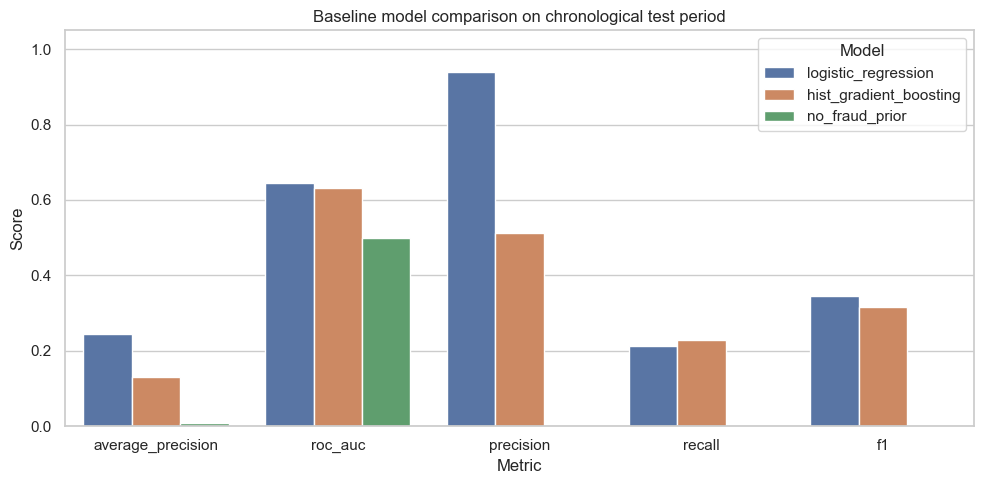

In [33]:
comparison_metrics = ['average_precision', 'roc_auc', 'precision', 'recall', 'f1']
plot_frame = (
    baseline_result.test_metrics.reset_index()
    .melt(id_vars='model', value_vars=comparison_metrics, var_name='metric', value_name='value')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_frame, x='metric', y='value', hue='model', ax=ax)
ax.set_title('Baseline model comparison on chronological test period')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(title='Model', loc='upper right')
fig.tight_layout()
save_figure(fig, figures_dir / 'baseline_model_metrics.png')
plt.show()

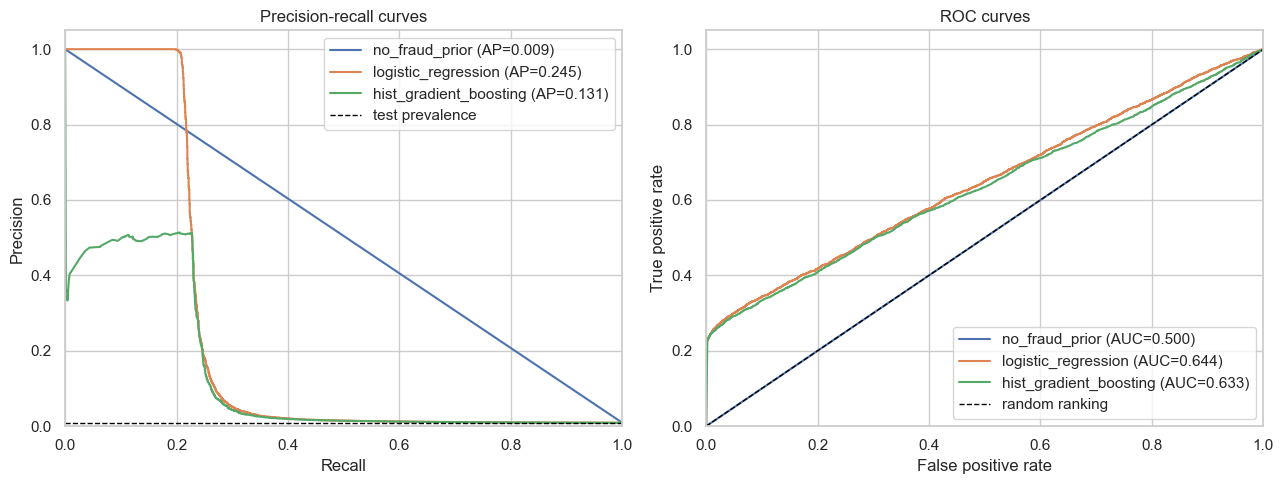

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
y_test_array = baseline_result.y_test.to_numpy()

for model_name, scores in baseline_result.test_scores.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_array, scores)
    axes[0].plot(
        recall_curve,
        precision_curve,
        label=f'{model_name} (AP={baseline_result.test_metrics.loc[model_name, "average_precision"]:.3f})',
    )
    fpr, tpr, _ = roc_curve(y_test_array, scores)
    axes[1].plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC={baseline_result.test_metrics.loc[model_name, "roc_auc"]:.3f})',
    )

test_prevalence = baseline_result.test_metrics['fraud_prevalence'].iloc[0]
axes[0].axhline(test_prevalence, color='black', linestyle='--', linewidth=1, label='test prevalence')
axes[0].set_title('Precision-recall curves')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='upper right')

axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='random ranking')
axes[1].set_title('ROC curves')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')

fig.tight_layout()
save_figure(fig, figures_dir / 'baseline_precision_recall_roc_curves.png')
plt.show()

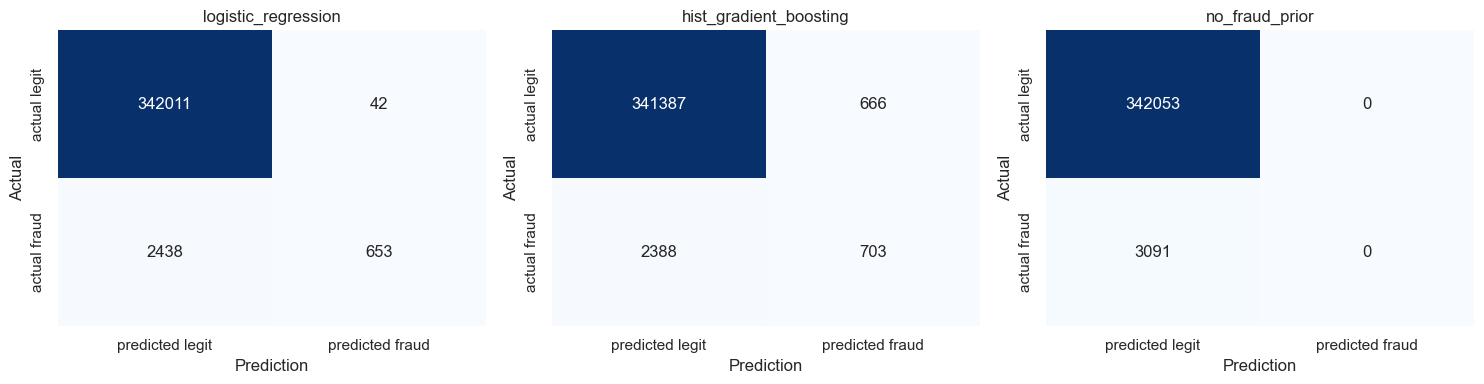

In [35]:
confusion_models = baseline_result.test_metrics.index.tolist()
fig, axes = plt.subplots(1, len(confusion_models), figsize=(5 * len(confusion_models), 4))
if len(confusion_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, confusion_models):
    row = baseline_result.test_metrics.loc[model_name]
    matrix = np.array([
        [row['true_negatives'], row['false_positives']],
        [row['false_negatives'], row['true_positives']],
    ], dtype=int)
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['predicted legit', 'predicted fraud'],
        yticklabels=['actual legit', 'actual fraud'],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Actual')

fig.tight_layout()
save_figure(fig, figures_dir / 'baseline_confusion_matrices.png')
plt.show()

## 34. Baseline interpretation

The baseline phase establishes an initial chronological benchmark. It does not test behavioral customer or terminal features, and it does not establish external validity beyond the synthetic generator.

In [36]:
best_model = baseline_result.test_metrics['average_precision'].idxmax()
best_metrics = baseline_result.test_metrics.loc[best_model]
trivial_ap = baseline_result.test_metrics.loc['no_fraud_prior', 'average_precision']

display(Markdown(
    '**Baseline findings**\n\n'
    f'- The chronological test period contains {len(baseline_result.y_test):,} transactions and '
    f'{int(baseline_result.y_test.sum()):,} fraud cases '
    f'({baseline_result.y_test.mean():.3%} prevalence).\n'
    f'- The strongest baseline by average precision is `{best_model}` with AP={best_metrics["average_precision"]:.3f} '
    f'and ROC-AUC={best_metrics["roc_auc"]:.3f}.\n'
    f'- The trivial prior baseline has AP={trivial_ap:.3f}, equal to the test prevalence, and detects no fraud '
    'at the fixed 0.5 threshold. This confirms why accuracy would be misleading.\n'
    '- Logistic regression and histogram gradient boosting improve ranking quality, but recall remains limited at '
    'validation-selected F1 thresholds. This is an expected consequence of rare-event detection with a narrow '
    'feature set.\n'
    '- The results are internally reproducible for the simulated benchmark, but they should not be interpreted as '
    'evidence that the same feature relationships hold in production payment data.'
))

**Baseline findings**

- The chronological test period contains 345,144 transactions and 3,091 fraud cases (0.896% prevalence).
- The strongest baseline by average precision is `logistic_regression` with AP=0.245 and ROC-AUC=0.644.
- The trivial prior baseline has AP=0.009, equal to the test prevalence, and detects no fraud at the fixed 0.5 threshold. This confirms why accuracy would be misleading.
- Logistic regression and histogram gradient boosting improve ranking quality, but recall remains limited at validation-selected F1 thresholds. This is an expected consequence of rare-event detection with a narrow feature set.
- The results are internally reproducible for the simulated benchmark, but they should not be interpreted as evidence that the same feature relationships hold in production payment data.